# E-Commerce Business Data Analysis

This project analyzes an e-commerce dataset to understand sales performance, product trends, and geographic distribution of customers. 

The analysis was performed using:
- Python (Pandas, Matplotlib, Seaborn)
- SQL (MySQL) for data extraction
- Power BI for dashboard visualization

## 1. Import Required Libraries

In this step, we import the necessary Python libraries used for data analysis and visualization.

- **Pandas** is used for data manipulation and analysis.
- **Matplotlib** is used to create basic visualizations.
- **Seaborn** is used for advanced statistical visualizations.

In [243]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

The cleaned dataset exported from SQL is loaded into a Pandas DataFrame. 

The dataset contains order information such as:
- order details
- customer location
- product categories
- payment values
- shipping costs

We check the shape of the dataset to confirm the number of rows and columns.

In [206]:
df = pd.read_csv("../data/processed/ecommerce_master.csv")

df.head()

,order_id,order_purchase_timestamp,order_status,customer_id,customer_city,customer_state,product_id,price,freight_value,product_category_name,payment_type,payment_value
0,2d1d5777f29a8ee6593cf90b85afb5b6,2017-08-01 22:31:01,delivered,e005b68469dd892804952168469745b5,santa helena,PR,0d79e2972015716ede4fabeb5b60f8c6,76.9,14.27,market_place,credit_card,91.17
1,2ad6c6594bf0917a25ff8b8918d4b7b0,2017-06-11 23:41:58,delivered,b413f8147ffaf8ad8f92fe4a60d59ed0,brasilia,DF,f4d705aa95ccca448e5b0deb6e5290ba,24.9,15.10,cama_mesa_banho,credit_card,40.00
2,068176c8a0550b07cddf7e05c8d55319,2018-01-13 18:13:53,delivered,f6dd501a7cd9672dac78ff3d26a9912d,porto alegre,RS,9328c3a5c42ae7b32d53e419f9b93d66,45.8,16.11,moveis_decoracao,boleto,123.82
3,068176c8a0550b07cddf7e05c8d55319,2018-01-13 18:13:53,delivered,f6dd501a7cd9672dac78ff3d26a9912d,porto alegre,RS,9328c3a5c42ae7b32d53e419f9b93d66,45.8,16.11,moveis_decoracao,boleto,123.82
4,175ba47aad2d017d2495c66b763a7df6,2017-08-05 22:15:00,delivered,890f8c3559b1bf4248a9adc64369228d,vicosa,MG,9defd1ffa1cecec71bc4a269ee97938d,49.9,15.10,moveis_decoracao,credit_card,130.00


## 3. Preview Dataset

Dataset Overview

Before performing analysis, we explore the dataset structure.

This step helps us understand:
- column names
- data types
- missing values
- general structure of the dataset

In [207]:
df.shape

(113390, 12)

In [208]:
df.columns

Index(['order_id', 'order_purchase_timestamp', 'order_status', 'customer_id',
       'customer_city', 'customer_state', 'product_id', 'price',
       'freight_value', 'product_category_name', 'payment_type',
       'payment_value'],
      dtype='object')

In [209]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  113390 non-null  object 
 1   order_purchase_timestamp  113390 non-null  object 
 2   order_status              113390 non-null  object 
 3   customer_id               113390 non-null  object 
 4   customer_city             113390 non-null  object 
 5   customer_state            113390 non-null  object 
 6   product_id                113390 non-null  object 
 7   price                     113390 non-null  float64
 8   freight_value             113390 non-null  float64
 9   product_category_name     113390 non-null  object 
 10  payment_type              113390 non-null  object 
 11  payment_value             113390 non-null  float64
dtypes: float64(3), object(9)
memory usage: 10.4+ MB


## 4. Convert Date Column


The `order_purchase_timestamp` column is converted to datetime format so that we can perform time-based analysis such as monthly revenue trends.

In [210]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  113390 non-null  object        
 1   order_purchase_timestamp  113390 non-null  datetime64[ns]
 2   order_status              113390 non-null  object        
 3   customer_id               113390 non-null  object        
 4   customer_city             113390 non-null  object        
 5   customer_state            113390 non-null  object        
 6   product_id                113390 non-null  object        
 7   price                     113390 non-null  float64       
 8   freight_value             113390 non-null  float64       
 9   product_category_name     113390 non-null  object        
 10  payment_type              113390 non-null  object        
 11  payment_value             113390 non-null  float64       
dtypes:

## 5. Create Month Column

Feature Engineering

A new column called `month` is created from the purchase timestamp. 

This column will allow us to analyze revenue trends on a monthly basis.

In [212]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

In [213]:
monthly_sales = df.groupby('month')['payment_value'].sum()
monthly_sales.head()

month
2016-10     62495.73
2016-12        19.62
2017-01    172487.07
2017-02    313470.32
2017-03    496731.66
Freq: M, Name: payment_value, dtype: float64

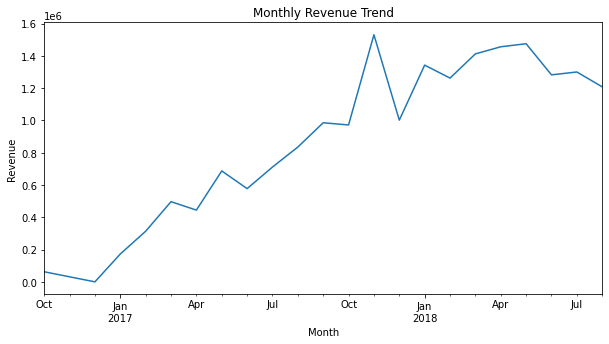

In [214]:
plt.figure(figsize=(10,5))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [215]:
top_categories = df.groupby('product_category_name')['payment_value'].sum().sort_values(ascending=False).head(10)

top_categories

product_category_name
cama_mesa_banho           1692557.09
beleza_saude              1620868.35
informatica_acessorios    1549252.47
moveis_decoracao          1393972.04
relogios_presentes        1387046.31
esporte_lazer             1349194.08
utilidades_domesticas     1069787.97
automotivo                 833610.84
ferramentas_jardim         810460.70
cool_stuff                 744339.94
Name: payment_value, dtype: float64

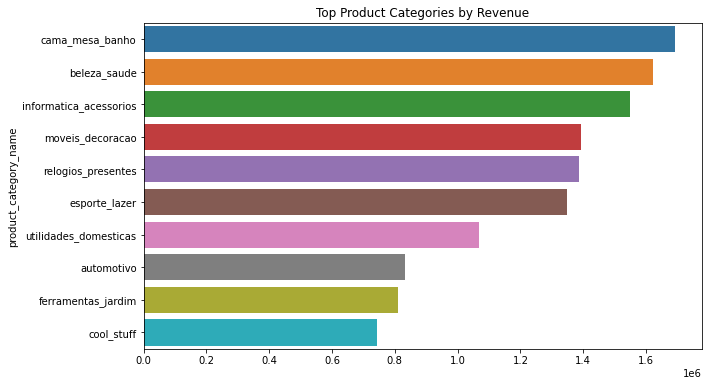

In [216]:
plt.figure(figsize=(10,6))

sns.barplot(x=top_categories.values, y=top_categories.index)

plt.title("Top Product Categories by Revenue")

plt.show()

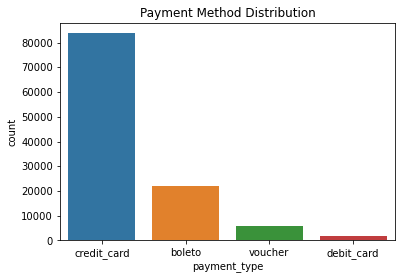

In [217]:
sns.countplot(data=df, x='payment_type')

plt.title("Payment Method Distribution")

plt.show()

In [218]:
total_revenue = df['payment_value'].sum()
total_orders = df['order_id'].nunique()
avg_order_value = df['payment_value'].mean()

print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value,2))

Total Revenue: 19530503.5
Total Orders: 95128
Average Order Value: 172.24


In [219]:
monthly_sales = df.groupby('month')['payment_value'].sum()
monthly_sales

month
2016-10      62495.73
2016-12         19.62
2017-01     172487.07
2017-02     313470.32
2017-03     496731.66
2017-04     444457.76
2017-05     687145.80
2017-06     577595.09
2017-07     711168.83
2017-08     835079.65
2017-09     985552.86
2017-10     972010.21
2017-11    1530815.84
2017-12    1001835.60
2018-01    1342632.07
2018-02    1262341.96
2018-03    1412277.50
2018-04    1456300.41
2018-05    1475249.63
2018-06    1282453.00
2018-07    1300181.74
2018-08    1208201.15
Freq: M, Name: payment_value, dtype: float64

In [220]:
top_products = df.groupby('product_id')['payment_value'].sum() \
                 .sort_values(ascending=False) \
                 .head(10)

top_products

product_id
5769ef0a239114ac3a854af00df129e4    109312.80
bb50f2e236e5eea0100680137654686c     81539.35
422879e10f46682990de24d770e7f83d     79512.22
d1c427060a0f73f6b889a5c7c61f2ac4     68038.66
d5991653e037ccb7af6ed7d94246b249     64143.26
6cdd53843498f92890544667809f1595     63665.41
aca2eb7d00ea1a7b8ebd4e68314663af     62975.07
a62e25e09e05e6faf31d90c6ec1aa3d1     62911.77
99a4788cb24856965c36a24e339b6058     61997.30
3dd2a17168ec895c781a9191c1e95ad7     58625.98
Name: payment_value, dtype: float64

In [221]:
df['order_status'].value_counts()

delivered    113383
canceled          7
Name: order_status, dtype: int64

## 6. Filter Delivered Orders


To ensure accurate revenue analysis, we filter only orders with the status **delivered**.

Cancelled orders are excluded because they do not generate revenue.

In [222]:
df_delivered = df[df['order_status'] == 'delivered']
df_delivered.shape

(113383, 13)

## 7. Calculate Business KPIs

## Key Business Metrics

We calculate important business KPIs:

- **Total Revenue:** Total value of all completed transactions.
- **Total Orders:** Number of unique orders.
- **Average Order Value (AOV):** Average spending per order.

These metrics provide a high-level overview of the business performance.

In [223]:
total_revenue = df_delivered['payment_value'].sum()
total_orders = df_delivered['order_id'].nunique()
avg_order_value = df_delivered['payment_value'].mean()

print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value,2))

Total Revenue: 19529614.7
Total Orders: 95122
Average Order Value: 172.24


## 8. Monthly Revenue Analysis & Revenue Trend Visualization

## Monthly Revenue Trend

Revenue is aggregated by month to analyze how sales changed over time. 

This helps identify seasonal patterns and periods of high demand.

## Revenue Trend Visualization

A line chart is used to visualize monthly revenue growth. 

This chart highlights periods of increased sales activity and overall business growth trends.

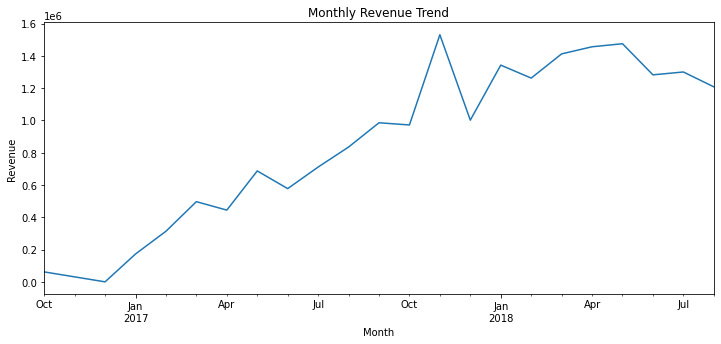

In [224]:
monthly_sales = df_delivered.groupby('month')['payment_value'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [225]:
top_categories = df_delivered.groupby('product_category_name')['payment_value'] \
                             .sum() \
                             .sort_values(ascending=False) \
                             .head(10)

top_categories

product_category_name
cama_mesa_banho           1692557.09
beleza_saude              1620684.04
informatica_acessorios    1549252.47
moveis_decoracao          1393972.04
relogios_presentes        1387046.31
esporte_lazer             1349158.47
utilidades_domesticas     1069787.97
automotivo                 833610.84
ferramentas_jardim         810460.70
cool_stuff                 744339.94
Name: payment_value, dtype: float64

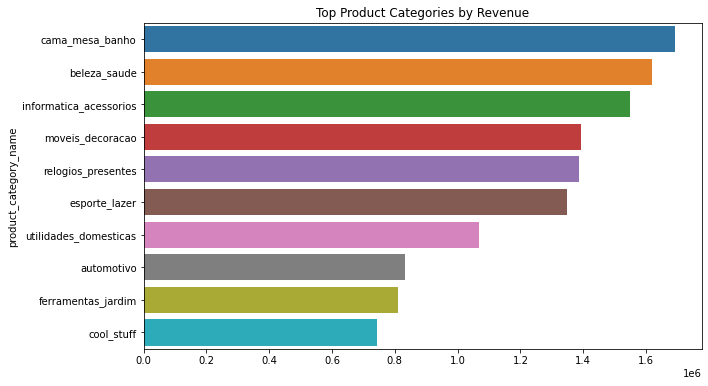

In [226]:
plt.figure(figsize=(10,6))

sns.barplot(x=top_categories.values, y=top_categories.index)

plt.title("Top Product Categories by Revenue")

plt.show()

## 9. Orders by State


Customer orders are analyzed by state to identify geographic demand patterns.

This helps determine which regions contribute the most to total sales.

In [227]:
state_orders = df_delivered.groupby('customer_state')['order_id'] \
                           .count() \
                           .sort_values(ascending=False) \
                           .head(10)

state_orders

customer_state
SP    47828
RJ    14648
MG    13233
RS     6284
PR     5790
SC     4160
BA     3859
DF     2389
GO     2319
ES     2288
Name: order_id, dtype: int64

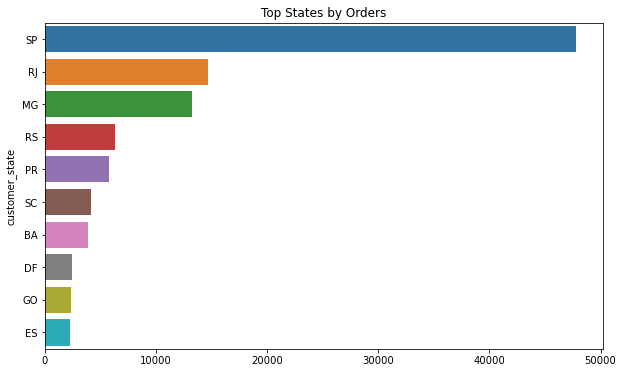

In [228]:
plt.figure(figsize=(10,6))

sns.barplot(x=state_orders.values, y=state_orders.index)

plt.title("Top States by Orders")

plt.show()

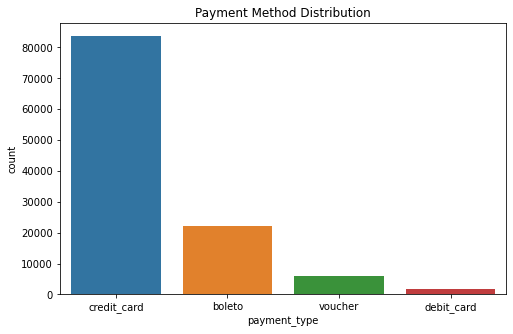

In [229]:
plt.figure(figsize=(8,5))

sns.countplot(data=df_delivered, x='payment_type')

plt.title("Payment Method Distribution")

plt.show()

In [230]:
df_delivered['customer_state'].value_counts().head(10)

SP    47828
RJ    14648
MG    13233
RS     6284
PR     5790
SC     4160
BA     3859
DF     2389
GO     2319
ES     2288
Name: customer_state, dtype: int64

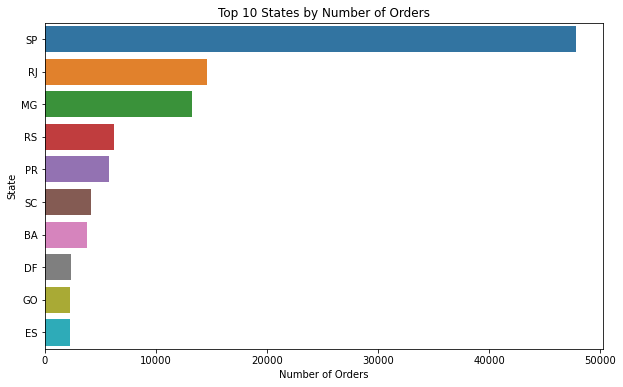

In [231]:
import matplotlib.pyplot as plt
import seaborn as sns

state_orders = df_delivered['customer_state'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=state_orders.values, y=state_orders.index)

plt.title("Top 10 States by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("State")

plt.show()

In [232]:
state_revenue = df_delivered.groupby('customer_state')['payment_value'] \
                            .sum() \
                            .sort_values(ascending=False) \
                            .head(10)

state_revenue

customer_state
SP    7313063.33
RJ    2657658.62
MG    2257817.15
RS    1090171.76
PR    1020152.26
BA     762368.88
SC     758552.01
GO     482929.45
DF     418039.12
ES     396343.83
Name: payment_value, dtype: float64

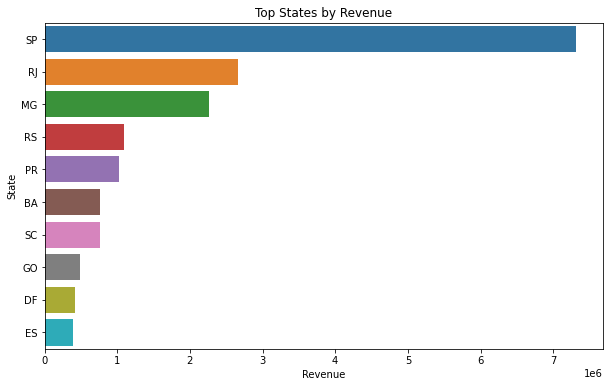

In [233]:
plt.figure(figsize=(10,6))

sns.barplot(x=state_revenue.values, y=state_revenue.index)

plt.title("Top States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")

plt.show()

In [234]:
df_delivered[['price','freight_value']].describe()

,price,freight_value
count,113383.000000,113383.000000
mean,120.185778,20.024318
std,182.766131,15.752799
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.900000,16.320000
75%,133.725000,21.200000
max,6735.000000,409.680000


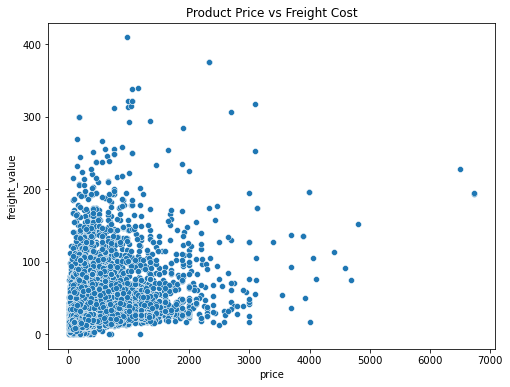

In [235]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='price', y='freight_value', data=df_delivered)

plt.title("Product Price vs Freight Cost")

plt.show()

## 10. Top Product Categories


We identify the top-performing product categories based on total revenue. 

This analysis helps understand which types of products generate the most sales.

In [236]:
top_categories = df_delivered.groupby('product_category_name')['payment_value'] \
                             .sum() \
                             .sort_values(ascending=False) \
                             .head(10)

top_categories

product_category_name
cama_mesa_banho           1692557.09
beleza_saude              1620684.04
informatica_acessorios    1549252.47
moveis_decoracao          1393972.04
relogios_presentes        1387046.31
esporte_lazer             1349158.47
utilidades_domesticas     1069787.97
automotivo                 833610.84
ferramentas_jardim         810460.70
cool_stuff                 744339.94
Name: payment_value, dtype: float64

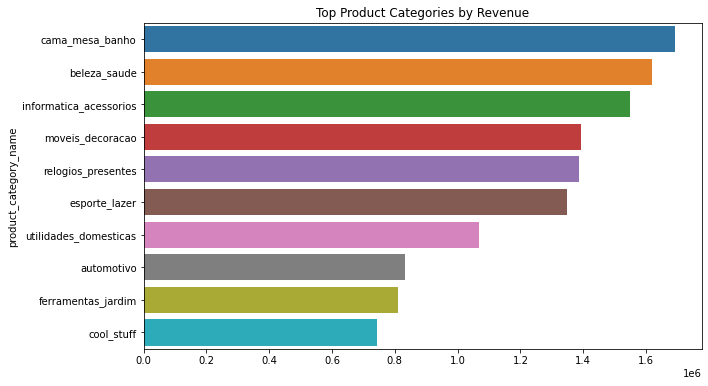

In [237]:
plt.figure(figsize=(10,6))

sns.barplot(x=top_categories.values, y=top_categories.index)

plt.title("Top Product Categories by Revenue")

plt.show()

In [238]:
df_delivered.groupby('customer_id')['order_id'].nunique().sort_values(ascending=False).head(10)

customer_id
00012a2ce6f8dcda20d059ce98491703    1
aa5c0aaed0105f447bd7e6198ae88108    1
aa5f87b79875f43b90b310decb62356e    1
aa5f5931b8901ae1ca4b8302f9b94c02    1
aa5e99afaf6a4dce3da0dee9f41beac8    1
aa5e567592c7fce76e3937e35c6a4ecb    1
aa5e341090958e5111abe3ba75bcfe87    1
aa5e0a0c36015d39de864189a2b00b09    1
aa5dfb0872b3828aa250acb54d387266    1
aa5de1c726fedb2c495cea4ead03d6d8    1
Name: order_id, dtype: int64

In [239]:
df_delivered['customer_id'].nunique()

95122

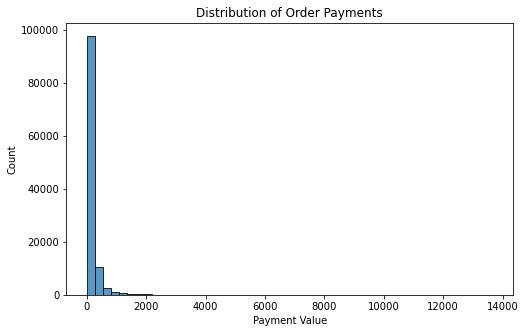

In [240]:
plt.figure(figsize=(8,5))

sns.histplot(df_delivered['payment_value'], bins=50)

plt.title("Distribution of Order Payments")
plt.xlabel("Payment Value")

plt.show()

## 11. Price and Freight Statistics

## Descriptive Statistics

Summary statistics are calculated for numeric columns including:

- product price
- shipping cost
- payment value

This helps understand the distribution and variability of order values.

In [244]:
df_delivered.describe()

,price,freight_value,payment_value
count,113383.000000,113383.000000,113383.000000
mean,120.185778,20.024318,172.244646
std,182.766131,15.752799,266.603827
min,0.850000,0.000000,0.000000
25%,39.900000,13.080000,61.000000
50%,74.900000,16.320000,108.120000
75%,133.725000,21.200000,189.370000
max,6735.000000,409.680000,13664.100000


## 12. Correlation Analysis

Correlation analysis is performed to understand relationships between:

- product price
- shipping cost
- payment value

This helps determine how these variables influence each other.

In [241]:
df_delivered[['price','freight_value','payment_value']].corr()

,price,freight_value,payment_value
price,1.000000,0.414985,0.736677
freight_value,0.414985,1.000000,0.372611
payment_value,0.736677,0.372611,1.000000


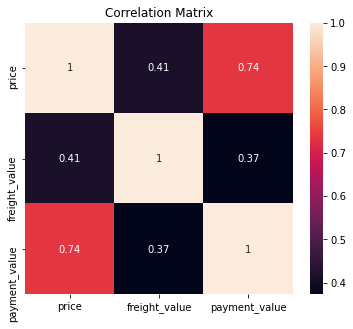

In [242]:
plt.figure(figsize=(6,5))

sns.heatmap(df_delivered[['price','freight_value','payment_value']].corr(), annot=True)

plt.title("Correlation Matrix")

plt.show()

In [89]:
df_delivered.to_csv("../data/processed/ecommerce_final.csv", index=False)

## Key Insights

- Total revenue exceeded **$19 million**.
- The average order value was approximately **$172**.
- São Paulo generated the highest number of orders and revenue.
- Home and lifestyle product categories were the top performers.
- Sales peaked during late 2017, likely due to seasonal promotions.